In [1]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone
import math
import cmocean
from geopy import distance
from scipy.stats import cumfreq
from scipy.interpolate import griddata
import shapefile
import xarray as xr

dmin=260

%matplotlib widget 
# Autosave every second:
%autosave 1

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Autosaving every 1 seconds


In [5]:
database_file = "../data/Level3_TD/L3_government.nc"
data_comb=xr.open_dataset(database_file,decode_times=False)
tnum=data_comb["time"].values
ds = xr.decode_cf(xr.Dataset({"time": ("time", data_comb.time.data,{"units":"seconds since 1970-01-01"})}))
data_comb["time"]=ds["time"].data


In [6]:
print(data_comb)

<xarray.Dataset>
Dimensions:       (time: 2, depth_interp: 2000)
Coordinates:
  * time          (time) datetime64[ns] 2008-10-16T10:16:15 2008-10-16T10:54:14
  * depth_interp  (depth_interp) float64 0.0 0.2 0.4 0.6 ... 399.4 399.6 399.8
Data variables: (12/20)
    datetime      (time) float64 ...
    min_depth     (time) float64 ...
    max_depth     (time) float64 ...
    Press         (depth_interp, time) float64 ...
    Temp          (depth_interp, time) float64 ...
    Cond          (depth_interp, time) float64 ...
    ...            ...
    thorpe        (depth_interp, time) float64 ...
    SALIN         (depth_interp, time) float64 ...
    Cond20        (depth_interp, time) float64 ...
    latitude      (time) float64 ...
    longitude     (time) float64 ...
    dist_GEF      (time) float64 ...
Attributes: (12/18)
    institution:          Eawag
    references:           james.runnalls@eawag.ch
    history:              See history on Renku
    conventions:          CF 1.7
    co

## Interpolated grid

Text(0, 0.5, 'Depth [m]')

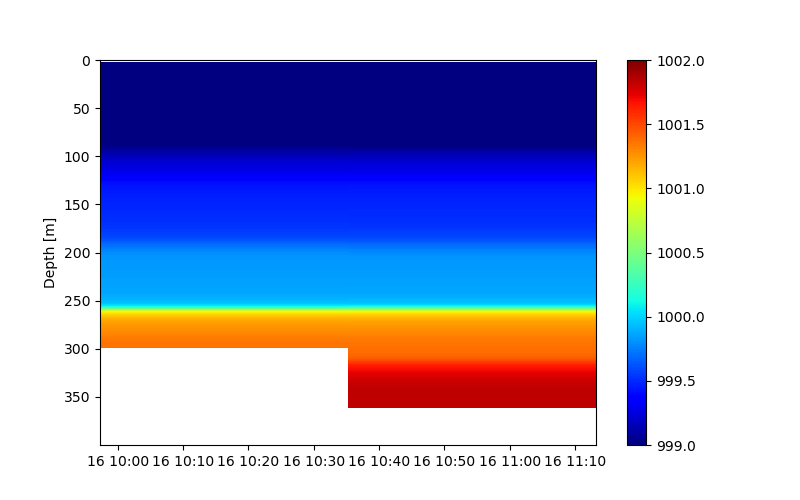

In [7]:
fig,ax = plt.subplots(figsize=(8,5))
z=data_comb["rho"]
x,y = np.meshgrid(data_comb["time"],data_comb["depth_interp"])
c = ax.pcolormesh(x,y,z,cmap='jet', vmin=999, vmax=1002)
ax.invert_yaxis()
cb=fig.colorbar(c, ax=ax)
#cb.set_label('$\rho$ [kg m$^{-3}$}]')
ax.set_ylabel('Depth [m]')


## Specific profiles

Text(0.5, 0, 'Cond20 [mS cm$^{-1}$]')

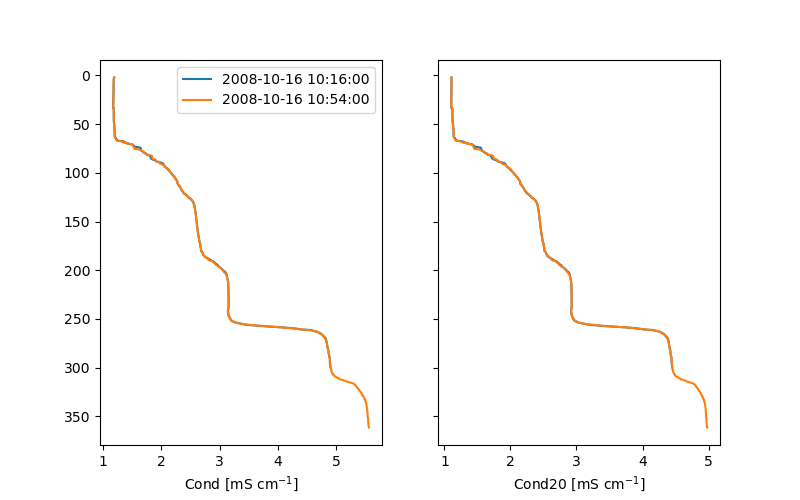

In [10]:
timeprof=[datetime(2008,10,16,10,16,0),datetime(2008,10,16,10,54,0)]
indprof=np.full((len(timeprof),),np.nan)

fig,ax = plt.subplots(1,2,figsize=(8,5),sharey=True)
for k in range(len(indprof)):
    indval=np.argmin(np.abs(tnum-timeprof[k].replace(tzinfo=timezone.utc).timestamp()))
    indprof[k]=indval
    ax[0].plot(data_comb["Cond"].values[:,indval],data_comb["depth_interp"].values)
    ax[1].plot(data_comb["Cond20"].values[:,indval],data_comb["depth_interp"].values)
ax[0].set_xlabel("Cond [mS cm$^{-1}$]")
ax[0].invert_yaxis()
ax[0].legend(timeprof)
ax[1].set_xlabel("Cond20 [mS cm$^{-1}$]")

In [4]:
data_comb.close()